In [47]:
from google.colab import files
import pandas as pd
import io

print("Upload your files when the button appears below")
print("Select both train.csv and insurance.csv at the same time using Ctrl+Click")

uploaded = files.upload()

train = None
insurance = None

for filename, content in uploaded.items():
    print("Processing:", filename)

    if 'train' in filename.lower() and filename.endswith('.csv'):
        train = pd.read_csv(io.BytesIO(content))
        print("Prudential dataset loaded")
        print("Shape:", train.shape[0], "rows x", train.shape[1], "columns")
        print("Columns preview:", list(train.columns[:6]))
        print("Target (Response) distribution:")
        print(train['Response'].value_counts().sort_index())

    elif 'insurance' in filename.lower() and filename.endswith('.csv'):
        insurance = pd.read_csv(io.BytesIO(content))
        print("Medical Cost dataset loaded")
        print("Shape:", insurance.shape[0], "rows x", insurance.shape[1], "columns")
        print("Columns:", list(insurance.columns))
        print("Sample data:")
        print(insurance.head(3))

print()
print("=" * 40)
if train is not None:
    print("train loaded:", train.shape[0], "rows x", train.shape[1], "cols")
else:
    print("train - NOT LOADED")

if insurance is not None:
    print("insurance loaded:", insurance.shape[0], "rows x", insurance.shape[1], "cols")
else:
    print("insurance - NOT LOADED")
print("=" * 40)

Upload your files when the button appears below
Select both train.csv and insurance.csv at the same time using Ctrl+Click


Saving insurance.csv to insurance.csv
Saving train.csv to train.csv
Processing: insurance.csv
Medical Cost dataset loaded
Shape: 1338 rows x 7 columns
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Sample data:
   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620
Processing: train.csv
Prudential dataset loaded
Shape: 59381 rows x 128 columns
Columns preview: ['Id', 'Product_Info_1', 'Product_Info_2', 'Product_Info_3', 'Product_Info_4', 'Product_Info_5']
Target (Response) distribution:
Response
1     6207
2     6552
3     1013
4     1428
5     5432
6    11233
7     8027
8    19489
Name: count, dtype: int64

train loaded: 59381 rows x 128 cols
insurance loaded: 1338 rows x 7 cols


**Step 2 - Sanity Check on both datasets**

In [48]:
import numpy as np

print("DATASET 1 - Prudential Life Insurance")
print("-" * 40)
print("Shape:", train.shape)
print("Missing values (top 10 columns):")
print(train.isnull().sum().sort_values(ascending=False).head(10))
print()
print("Target distribution (Response 1-8):")
print(train['Response'].value_counts(normalize=True).sort_index().round(3))

print()
print("DATASET 2 - Medical Cost Personal")
print("-" * 40)
print("Shape:", insurance.shape)
print("Columns:", list(insurance.columns))
print("Missing values:", insurance.isnull().sum().sum())
print("Charges summary:")
print(insurance['charges'].describe().round(2))

DATASET 1 - Prudential Life Insurance
----------------------------------------
Shape: (59381, 128)
Missing values (top 10 columns):
Medical_History_10     58824
Medical_History_32     58274
Medical_History_24     55580
Medical_History_15     44596
Family_Hist_5          41811
Family_Hist_3          34241
Family_Hist_2          28656
Insurance_History_5    25396
Family_Hist_4          19184
Employment_Info_6      10854
dtype: int64

Target distribution (Response 1-8):
Response
1    0.105
2    0.110
3    0.017
4    0.024
5    0.091
6    0.189
7    0.135
8    0.328
Name: proportion, dtype: float64

DATASET 2 - Medical Cost Personal
----------------------------------------
Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Missing values: 0
Charges summary:
count     1338.00
mean     13270.42
std      12110.01
min       1121.87
25%       4740.29
50%       9382.03
75%      16639.91
max      63770.43
Name: charges, dtype: float64


**Step 3 - SQL Layer**

In [49]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
train.to_sql('policyholders', conn, if_exists='replace', index=False)
insurance.to_sql('medical_cost', conn, if_exists='replace', index=False)

print("Both tables loaded into SQLite successfully")
print()

# Query 1: Risk score by age group
q1 = """
    SELECT
        CASE
            WHEN Ins_Age < 0.30 THEN 'Young'
            WHEN Ins_Age BETWEEN 0.30 AND 0.60 THEN 'Middle'
            ELSE 'Senior'
        END AS age_group,
        COUNT(*) AS total_policies,
        ROUND(AVG(Response), 3) AS avg_risk_score,
        SUM(CASE WHEN Response >= 7 THEN 1 ELSE 0 END) AS high_risk_count,
        ROUND(100.0 * SUM(CASE WHEN Response >= 7 THEN 1 ELSE 0 END) / COUNT(*), 2) AS high_risk_pct
    FROM policyholders
    GROUP BY age_group
    ORDER BY avg_risk_score DESC
"""
print("Risk Distribution by Age Group:")
print(pd.read_sql(q1, conn).to_string(index=False))
print()

# Query 2: BMI quartile vs risk
q2 = """
    SELECT
        CASE
            WHEN BMI < 0.35 THEN 'Q1 Low'
            WHEN BMI < 0.48 THEN 'Q2 Normal'
            WHEN BMI < 0.60 THEN 'Q3 High'
            ELSE 'Q4 Very High'
        END AS bmi_quartile,
        COUNT(*) AS count,
        ROUND(AVG(Response), 3) AS avg_risk,
        ROUND(100.0 * SUM(CASE WHEN Response >= 7 THEN 1 ELSE 0 END) / COUNT(*), 2) AS high_risk_pct
    FROM policyholders
    WHERE BMI IS NOT NULL
    GROUP BY bmi_quartile
    ORDER BY avg_risk DESC
"""
print("Risk by BMI Quartile:")
print(pd.read_sql(q2, conn).to_string(index=False))
print()

# Query 3: Smoker charges from medical cost dataset
q3 = """
    SELECT
        smoker,
        COUNT(*) AS count,
        ROUND(AVG(charges), 2) AS avg_charges,
        ROUND(MIN(charges), 2) AS min_charges,
        ROUND(MAX(charges), 2) AS max_charges,
        ROUND(AVG(bmi), 2) AS avg_bmi
    FROM medical_cost
    GROUP BY smoker
"""
print("Charges by Smoker Status:")
print(pd.read_sql(q3, conn).to_string(index=False))

Both tables loaded into SQLite successfully

Risk Distribution by Age Group:
age_group  total_policies  avg_risk_score  high_risk_count  high_risk_pct
    Young           20834           6.168            11600          55.68
   Middle           27275           5.581            12112          44.41
   Senior           11272           4.789             3804          33.75

Risk by BMI Quartile:
bmi_quartile  count  avg_risk  high_risk_pct
      Q1 Low   8793     6.601          69.79
   Q2 Normal  26706     6.118          58.17
     Q3 High  16080     5.253          34.91
Q4 Very High   7802     3.693           2.95

Charges by Smoker Status:
smoker  count  avg_charges  min_charges  max_charges  avg_bmi
    no   1064      8434.27      1121.87     36910.61    30.65
   yes    274     32050.23     12829.46     63770.43    30.71


**Step 4 - EDA Visualizations with Matplotlib charts**

/tmp/ipykernel_2890/1034627233.py:56: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



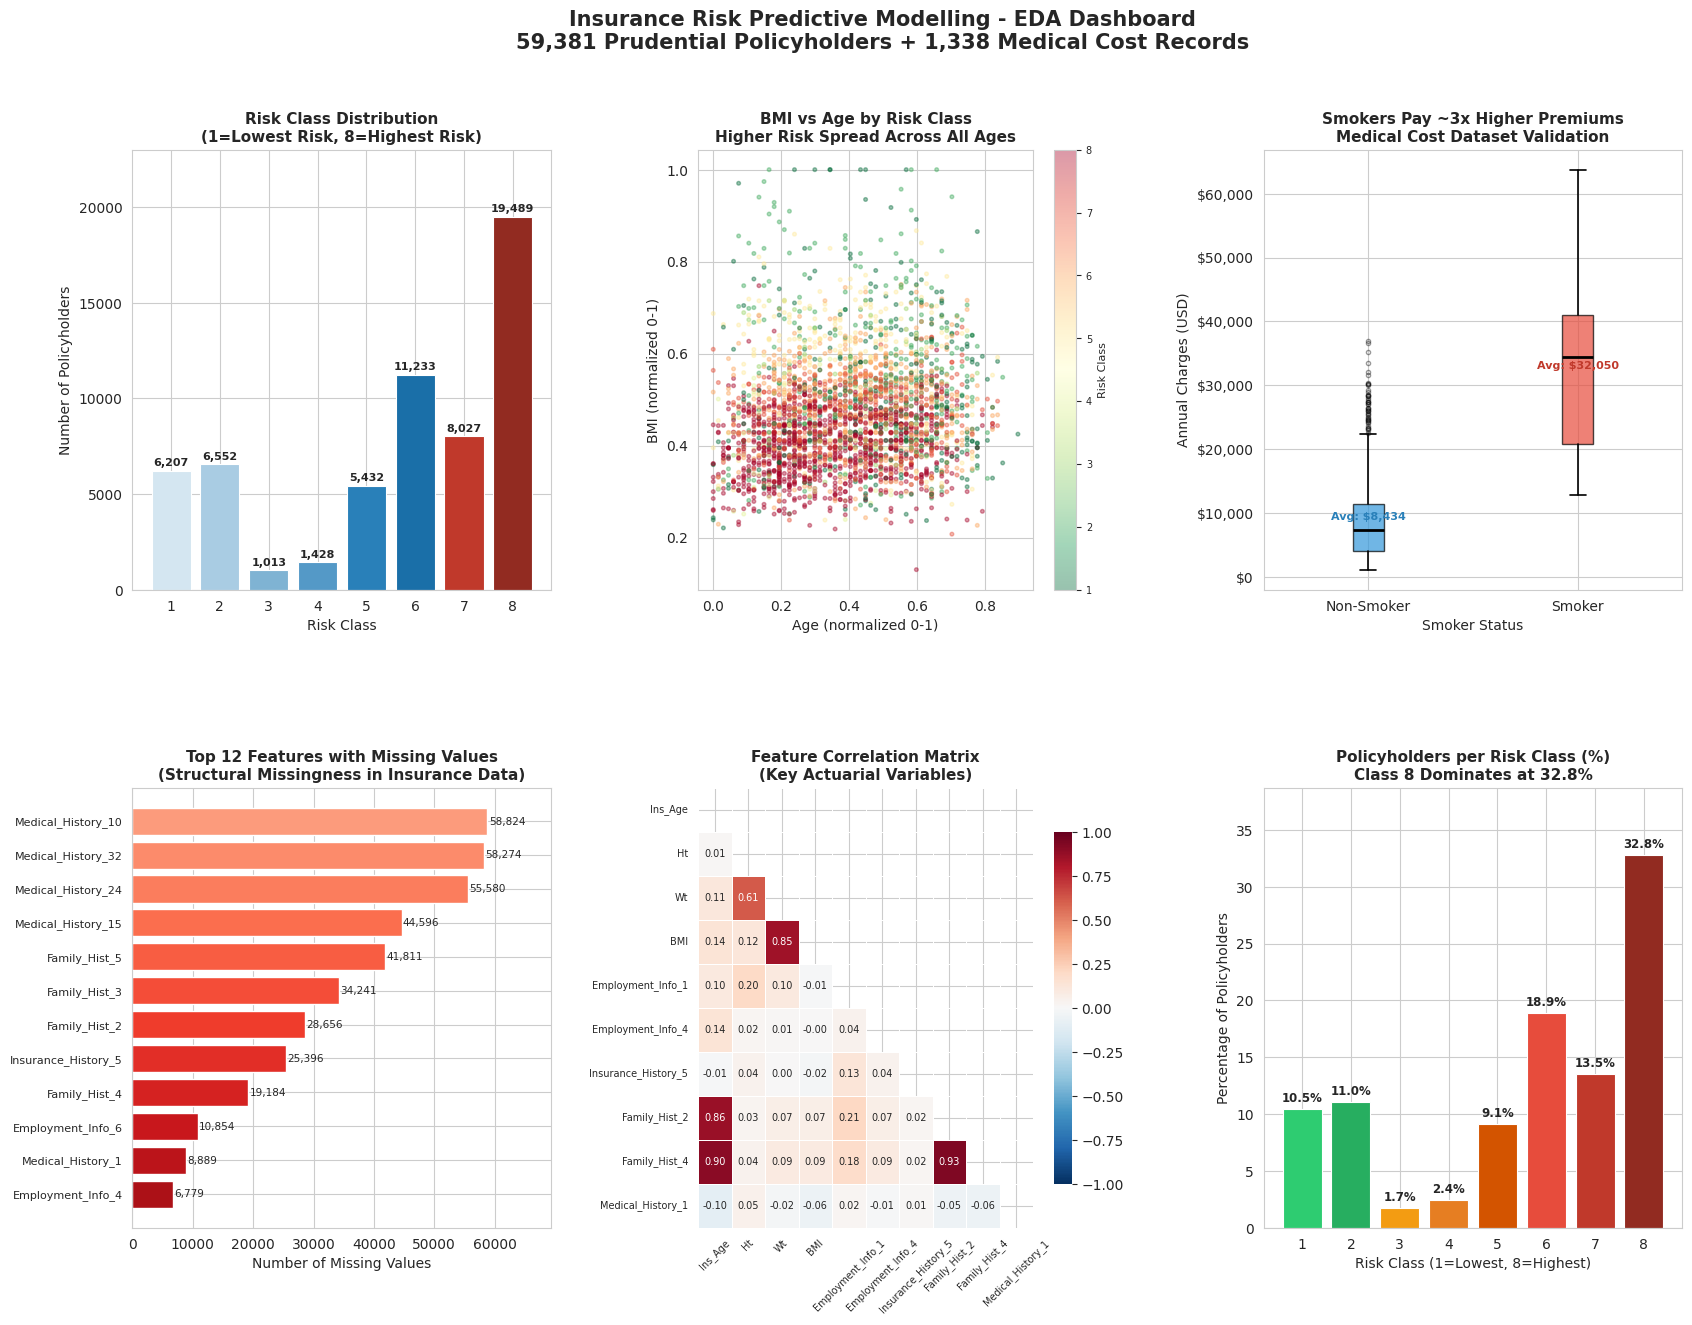

EDA dashboard saved - will render correctly on GitHub


In [50]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Insurance Risk Predictive Modelling - EDA Dashboard\n59,381 Prudential Policyholders + 1,338 Medical Cost Records',
             fontsize=15, fontweight='bold')

# ---------------------------------------------------------------
# Plot 1: Risk Class Distribution
# ---------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
response_counts = train['Response'].value_counts().sort_index()
bar_colors = ['#d4e6f1','#a9cce3','#7fb3d3','#5499c7',
              '#2980b9','#1a6fa8','#c0392b','#922b21']
bars = ax1.bar(response_counts.index.astype(str),
               response_counts.values,
               color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, response_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 150,
             f'{val:,}', ha='center', va='bottom',
             fontsize=8, fontweight='bold')
ax1.set_title('Risk Class Distribution\n(1=Lowest Risk, 8=Highest Risk)',
              fontweight='bold', fontsize=11)
ax1.set_xlabel('Risk Class')
ax1.set_ylabel('Number of Policyholders')
ax1.set_ylim(0, response_counts.max() * 1.18)

# ---------------------------------------------------------------
# Plot 2: BMI vs Age scatter colored by risk
# ---------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
sample = train.dropna(subset=['BMI']).sample(3000, random_state=42)
sc = ax2.scatter(sample['Ins_Age'], sample['BMI'],
                 c=sample['Response'], cmap='RdYlGn_r',
                 alpha=0.4, s=7, vmin=1, vmax=8)
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Risk Class', fontsize=8)
cbar.ax.tick_params(labelsize=7)
ax2.set_title('BMI vs Age by Risk Class\nHigher Risk Spread Across All Ages',
              fontweight='bold', fontsize=11)
ax2.set_xlabel('Age (normalized 0-1)')
ax2.set_ylabel('BMI (normalized 0-1)')

# ---------------------------------------------------------------
# Plot 3: Smoker vs Charges boxplot
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
smoker_no  = insurance[insurance['smoker'] == 'no']['charges']
smoker_yes = insurance[insurance['smoker'] == 'yes']['charges']
bp = ax3.boxplot(
    [smoker_no, smoker_yes],
    labels=['Non-Smoker', 'Smoker'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.7)
ax3.set_title('Smokers Pay ~3x Higher Premiums\nMedical Cost Dataset Validation',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Smoker Status')
ax3.set_ylabel('Annual Charges (USD)')
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${int(x):,}'))
avg_no  = smoker_no.mean()
avg_yes = smoker_yes.mean()
ax3.text(1, avg_no  + 500, f'Avg: ${avg_no:,.0f}',
         ha='center', fontsize=8, color='#2980b9', fontweight='bold')
ax3.text(2, avg_yes + 500, f'Avg: ${avg_yes:,.0f}',
         ha='center', fontsize=8, color='#c0392b', fontweight='bold')

# ---------------------------------------------------------------
# Plot 4: Missing Values
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 0])
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(12)
colors_m = plt.cm.Reds(np.linspace(0.35, 0.85, len(missing)))
bars4 = ax4.barh(range(len(missing)), missing.values,
                  color=colors_m, edgecolor='white')
ax4.set_yticks(range(len(missing)))
ax4.set_yticklabels(missing.index, fontsize=8)
ax4.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars4, missing.values)):
    ax4.text(val + 200, i, f'{val:,}',
             va='center', fontsize=7.5)
ax4.set_title('Top 12 Features with Missing Values\n(Structural Missingness in Insurance Data)',
              fontweight='bold', fontsize=11)
ax4.set_xlabel('Number of Missing Values')
ax4.set_xlim(0, missing.max() * 1.18)

# ---------------------------------------------------------------
# Plot 5: Correlation Heatmap
# ---------------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
key_cols = ['Ins_Age', 'Ht', 'Wt', 'BMI',
            'Employment_Info_1', 'Employment_Info_4',
            'Insurance_History_5', 'Family_Hist_2',
            'Family_Hist_4', 'Medical_History_1']
key_cols = [c for c in key_cols if c in train.columns]
corr = train[key_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax5, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, mask=mask,
            linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax5.set_title('Feature Correlation Matrix\n(Key Actuarial Variables)',
              fontweight='bold', fontsize=11)
ax5.tick_params(axis='x', rotation=45, labelsize=7)
ax5.tick_params(axis='y', rotation=0, labelsize=7)

# ---------------------------------------------------------------
# Plot 6: Risk Class Percentage
# ---------------------------------------------------------------
ax6 = fig.add_subplot(gs[1, 2])
risk_pct = (train['Response'].value_counts(normalize=True)
            .sort_index() * 100)
colors6 = ['#2ecc71','#27ae60','#f39c12','#e67e22',
            '#d35400','#e74c3c','#c0392b','#922b21']
bars6 = ax6.bar(risk_pct.index.astype(str),
                risk_pct.values,
                color=colors6, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars6, risk_pct.values):
    ax6.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.4,
             f'{val:.1f}%',
             ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')
ax6.set_title('Policyholders per Risk Class (%)\nClass 8 Dominates at 32.8%',
              fontweight='bold', fontsize=11)
ax6.set_xlabel('Risk Class (1=Lowest, 8=Highest)')
ax6.set_ylabel('Percentage of Policyholders')
ax6.set_ylim(0, risk_pct.max() * 1.18)

plt.savefig('eda_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("EDA dashboard saved - will render correctly on GitHub")

**Step 5 - Feature Engineering and Train/Test Split**

In [51]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

def preprocess(df):
    df = df.copy()

    # Create binary target: High Risk = Response 7 or 8
    if 'Response' in df.columns:
        df['HighRisk'] = (df['Response'] >= 7).astype(int)
        df.drop(columns=['Response'], inplace=True)

    # Create age band before encoding, keep it for fairness analysis later
    df['age_band'] = pd.cut(
        df['Ins_Age'],
        bins=[0, 0.30, 0.60, 1.0],
        labels=['Young', 'Middle', 'Senior']
    )

    # Drop ID and high cardinality text column
    drop_cols = ['Id', 'Product_Info_2']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Encode all remaining categorical columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # Encode age_band separately
    if 'age_band' in df.columns:
        df['age_band'] = LabelEncoder().fit_transform(df['age_band'].astype(str))

    # Impute missing values using median strategy
    imputer = SimpleImputer(strategy='median')
    df_imputed = pd.DataFrame(
        imputer.fit_transform(df),
        columns=df.columns
    )

    return df_imputed

train_clean = preprocess(train)

# Separate features and target
X = train_clean.drop(columns=['HighRisk'])
y = train_clean['HighRisk']

# 80/20 train test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Feature engineering complete")
print()
print("Train set:", X_train.shape[0], "rows x", X_train.shape[1], "features")
print("Test set :", X_test.shape[0], "rows x", X_test.shape[1], "features")
print()
print("High risk rate in train:", round(y_train.mean() * 100, 2), "%")
print("High risk rate in test :", round(y_test.mean() * 100, 2), "%")
print()
print("Sample of cleaned features:")
print(pd.DataFrame(X_train_sc, columns=X_train.columns).head(3).round(3))

Feature engineering complete

Train set: 47504 rows x 126 features
Test set : 11877 rows x 126 features

High risk rate in train: 46.34 %
High risk rate in test : 46.34 %

Sample of cleaned features:
   Product_Info_1  Product_Info_3  Product_Info_4  Product_Info_5  \
0          -0.165           0.313           2.370          -0.084   
1          -0.165           0.313          -0.168          -0.084   
2          -0.165           0.313           0.557          -0.084   

   Product_Info_6  Product_Info_7  Ins_Age     Ht     Wt    BMI  ...  \
0           0.441          -0.151   -1.073 -0.217  0.664  1.033  ...   
1          -2.266          -0.151    0.818 -1.444 -1.214 -0.727  ...   
2           0.441          -0.151    0.364  1.255  1.720  1.178  ...   

   Medical_Keyword_40  Medical_Keyword_41  Medical_Keyword_42  \
0              -0.245              -0.101              -0.219   
1              -0.245              -0.101              -0.219   
2              -0.245              -0.1

**Step 6 - Python GLM (statsmodels)**

In [52]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
import numpy as np

X_train_sm = sm.add_constant(X_train_sc)
X_test_sm  = sm.add_constant(X_test_sc)

glm_model  = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Binomial(link=sm.families.links.Logit())
)
glm_result = glm_model.fit()

print(glm_result.summary())

glm_probs = glm_result.predict(X_test_sm)
glm_auc   = roc_auc_score(y_test, glm_probs)

print()
print("Python GLM (statsmodels) Test AUC:", round(glm_auc, 4))
print("This is your baseline AUC before any tuning")

                 Generalized Linear Model Regression Results                  
Dep. Variable:               HighRisk   No. Observations:                47504
Model:                            GLM   Df Residuals:                    47377
Model Family:                Binomial   Df Model:                          126
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21284.
Date:                Sun, 19 Apr 2026   Deviance:                       42567.
Time:                        22:05:17   Pearson chi2:                 4.92e+04
No. Iterations:                     9   Pseudo R-squ. (CS):             0.3842
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5577      0.017    -32.629      0.0

**Step 7 - GLM Coefficient Plot**

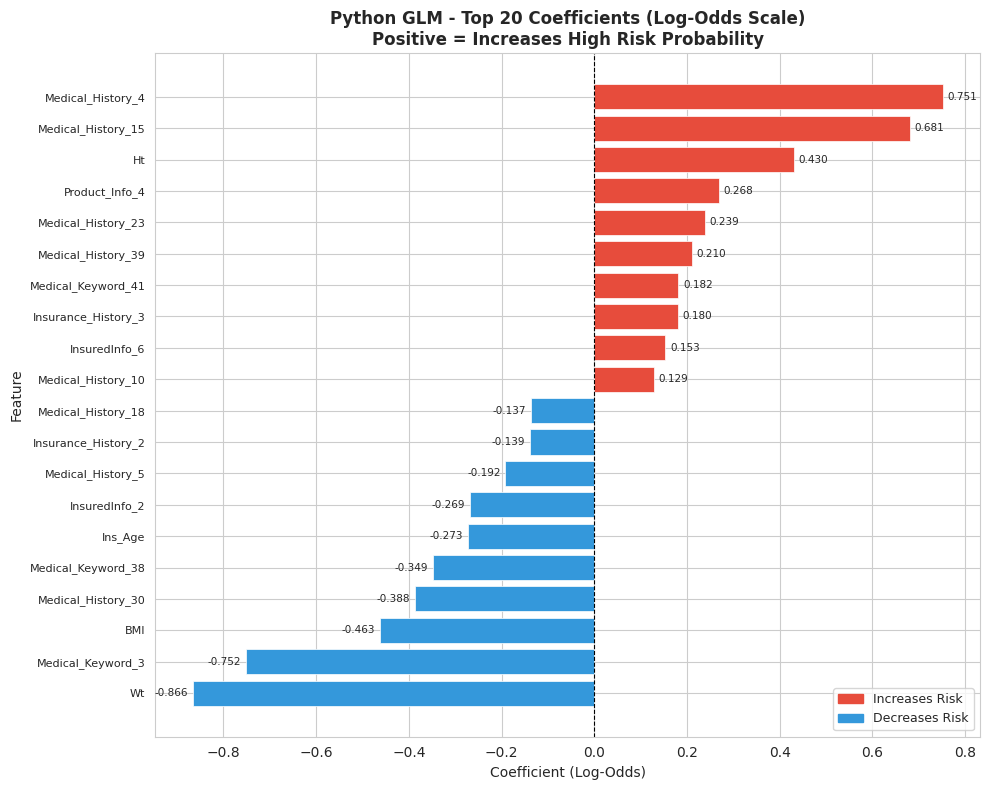

Top 5 risk-increasing features:
           feature     coef       pvalue
 Medical_History_4 0.751059 0.000000e+00
Medical_History_15 0.681412 0.000000e+00
                Ht 0.430418 1.458620e-07
    Product_Info_4 0.268370 1.692076e-76
Medical_History_23 0.238597 6.919349e-16

Top 5 risk-decreasing features:
           feature      coef        pvalue
                Wt -0.866390  3.880639e-08
 Medical_Keyword_3 -0.752040  2.403021e-70
               BMI -0.462604  1.929486e-04
Medical_History_30 -0.387785 1.503780e-102
Medical_Keyword_38 -0.348822  3.384218e-05


In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

coef_series = glm_result.params[1:]
pval_series = glm_result.pvalues[1:]

coef_df = pd.DataFrame({
    'feature': X_train.columns.tolist(),
    'coef':    coef_series,
    'pvalue':  pval_series
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)
coef_df = coef_df.sort_values('coef', ascending=True)

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coef']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(coef_df['feature'], coef_df['coef'],
               color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

for bar, val in zip(bars, coef_df['coef']):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=7.5)

red_patch  = plt.Rectangle((0,0),1,1, color='#e74c3c', label='Increases Risk')
blue_patch = plt.Rectangle((0,0),1,1, color='#3498db', label='Decreases Risk')
ax.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=9)

ax.set_title('Python GLM - Top 20 Coefficients (Log-Odds Scale)\nPositive = Increases High Risk Probability',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Coefficient (Log-Odds)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('glm_coefficients.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Top 5 risk-increasing features:")
top_pos = coef_df[coef_df['coef'] > 0].sort_values('coef', ascending=False).head(5)
print(top_pos[['feature','coef','pvalue']].to_string(index=False))
print()
print("Top 5 risk-decreasing features:")
top_neg = coef_df[coef_df['coef'] < 0].sort_values('coef').head(5)
print(top_neg[['feature','coef','pvalue']].to_string(index=False))

**Step 8 - ML Model Benchmarking**

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
}

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results   = {}
all_probs = {'Python GLM': glm_probs}

print("Training all models with 5-fold cross-validation")
print("This will take 3-5 minutes for Random Forest and Gradient Boosting")
print()

for name, model in models.items():
    t0        = time.time()
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train_sc, y_train)
    probs     = model.predict_proba(X_test_sc)[:, 1]
    test_auc  = roc_auc_score(y_test, probs)
    elapsed   = round(time.time() - t0, 1)

    results[name] = {
        'CV AUC Mean': round(cv_scores.mean(), 4),
        'CV AUC Std':  round(cv_scores.std(), 4),
        'Test AUC':    round(test_auc, 4),
        'Time (s)':    elapsed
    }
    all_probs[name] = probs

    print(name)
    print("  CV AUC:", round(cv_scores.mean(), 4), "+-", round(cv_scores.std(), 4))
    print("  Test AUC:", round(test_auc, 4))
    print("  Time:", elapsed, "seconds")
    print()

results_df = pd.DataFrame(results).T.sort_values('Test AUC', ascending=False)
print("Final Leaderboard:")
print(results_df.to_string())

Training all models with 5-fold cross-validation
This will take 3-5 minutes for Random Forest and Gradient Boosting

Logistic Regression
  CV AUC: 0.867 +- 0.0011
  Test AUC: 0.8655
  Time: 7.9 seconds

Decision Tree
  CV AUC: 0.8674 +- 0.0016
  Test AUC: 0.8692
  Time: 4.1 seconds

Random Forest
  CV AUC: 0.8853 +- 0.0011
  Test AUC: 0.8858
  Time: 68.4 seconds

Gradient Boosting
  CV AUC: 0.9001 +- 0.0009
  Test AUC: 0.9011
  Time: 474.7 seconds

Final Leaderboard:
                     CV AUC Mean  CV AUC Std  Test AUC  Time (s)
Gradient Boosting         0.9001      0.0009    0.9011     474.7
Random Forest             0.8853      0.0011    0.8858      68.4
Decision Tree             0.8674      0.0016    0.8692       4.1
Logistic Regression       0.8670      0.0011    0.8655       7.9


**Step 9 - Model Comparison Charts**

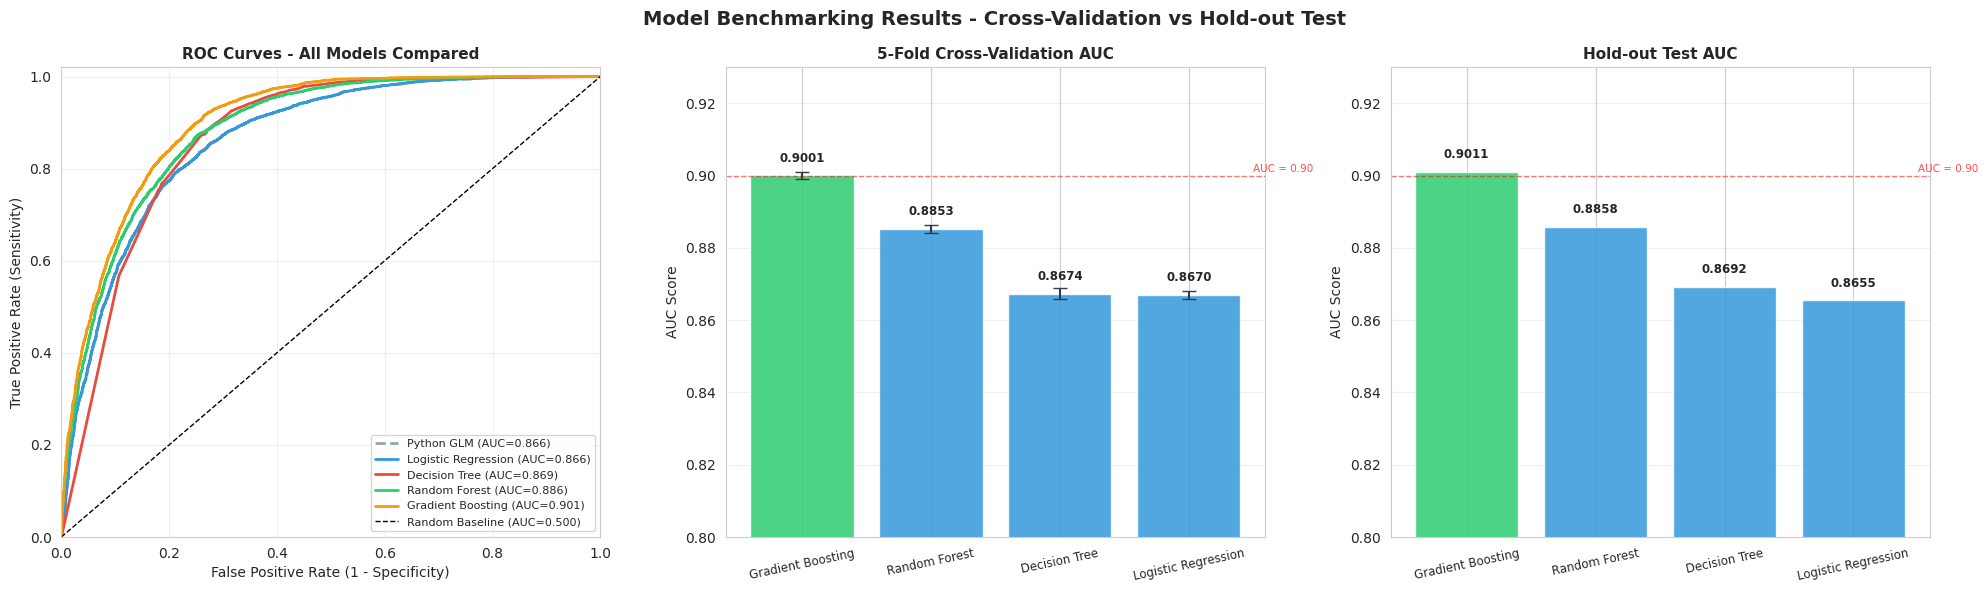

Best model by Test AUC: Gradient Boosting
Best Test AUC: 0.9011


In [55]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

color_map = {
    'Python GLM':         '#95a5a6',
    'Logistic Regression':'#3498db',
    'Decision Tree':      '#e74c3c',
    'Random Forest':      '#2ecc71',
    'Gradient Boosting':  '#f39c12'
}
line_styles = {
    'Python GLM':         '--',
    'Logistic Regression':'-',
    'Decision Tree':      '-',
    'Random Forest':      '-',
    'Gradient Boosting':  '-'
}

model_names = results_df.index.tolist()
cv_means    = results_df['CV AUC Mean'].tolist()
cv_stds     = results_df['CV AUC Std'].tolist()
test_aucs   = results_df['Test AUC'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Benchmarking Results - Cross-Validation vs Hold-out Test',
             fontweight='bold', fontsize=14)

# Left: ROC Curves
ax1 = axes[0]
for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val     = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr,
             color=color_map.get(name, '#333333'),
             linestyle=line_styles.get(name, '-'),
             linewidth=2,
             label=f'{name} (AUC={auc_val:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Baseline (AUC=0.500)')
ax1.set_title('ROC Curves - All Models Compared',
              fontweight='bold', fontsize=11)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.legend(loc='lower right', fontsize=8)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])
ax1.grid(True, alpha=0.3)

# Middle: CV AUC with error bars
ax2 = axes[1]
bar_colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(model_names))]
bars2 = ax2.bar(model_names, cv_means,
                yerr=cv_stds, capsize=5,
                color=bar_colors, alpha=0.85,
                edgecolor='white',
                error_kw=dict(linewidth=1.5, ecolor='#2c3e50'))
for bar, val in zip(bars2, cv_means):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.003,
             f'{val:.4f}',
             ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')
ax2.set_title('5-Fold Cross-Validation AUC',
              fontweight='bold', fontsize=11)
ax2.set_ylabel('AUC Score')
ax2.set_ylim(0.80, 0.93)
ax2.tick_params(axis='x', rotation=12, labelsize=8.5)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0.90, color='red', linestyle='--',
            linewidth=1, alpha=0.5)
ax2.text(len(model_names) - 0.5, 0.901,
         'AUC = 0.90', color='red', fontsize=7.5, alpha=0.7)

# Right: Hold-out Test AUC
ax3 = axes[2]
bars3 = ax3.bar(model_names, test_aucs,
                color=bar_colors, alpha=0.85,
                edgecolor='white')
for bar, val in zip(bars3, test_aucs):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.003,
             f'{val:.4f}',
             ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')
ax3.set_title('Hold-out Test AUC',
              fontweight='bold', fontsize=11)
ax3.set_ylabel('AUC Score')
ax3.set_ylim(0.80, 0.93)
ax3.tick_params(axis='x', rotation=12, labelsize=8.5)
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=0.90, color='red', linestyle='--',
            linewidth=1, alpha=0.5)
ax3.text(len(model_names) - 0.5, 0.901,
         'AUC = 0.90', color='red', fontsize=7.5, alpha=0.7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Best model by Test AUC:", results_df.index[0])
print("Best Test AUC:", results_df['Test AUC'].iloc[0])

**Step 10 - Feature Importance from Random Forest**

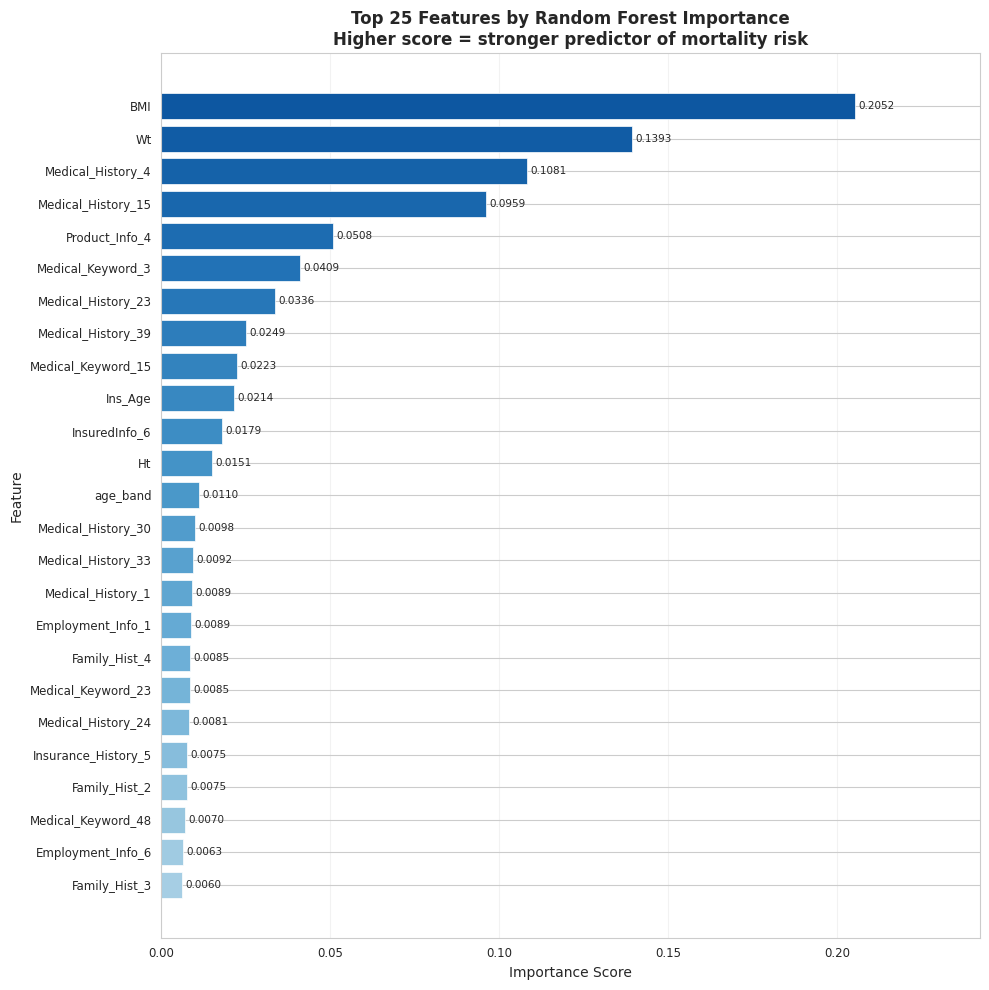

Top 10 most important features:
----------------------------------------
1.  BMI  -  0.2052
2.  Wt  -  0.1393
3.  Medical_History_4  -  0.1081
4.  Medical_History_15  -  0.0959
5.  Product_Info_4  -  0.0508
6.  Medical_Keyword_3  -  0.0409
7.  Medical_History_23  -  0.0336
8.  Medical_History_39  -  0.0249
9.  Medical_Keyword_15  -  0.0223
10.  Ins_Age  -  0.0214


In [56]:
import matplotlib.pyplot as plt
import numpy as np

rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(25)

feat_imp_plot = feat_imp.sort_values(ascending=True)

colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(feat_imp_plot)))

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(feat_imp_plot.index,
               feat_imp_plot.values,
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, feat_imp_plot.values):
    ax.text(val + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}',
            va='center', ha='left', fontsize=7.5)

ax.set_title('Top 25 Features by Random Forest Importance\n'
             'Higher score = stronger predictor of mortality risk',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=8.5)
ax.set_xlim(0, feat_imp_plot.max() * 1.18)
ax.grid(True, alpha=0.25, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

top_features = feat_imp.index.tolist()
print("Top 10 most important features:")
print("-" * 40)
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(str(i) + ".  " + feat + "  -  " + str(round(imp, 4)))

**Step 11 - SHAP Diagnostics**

In [57]:
!pip install -q shap
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the Gradient Boosting model already trained in Step 8
# Pull it out of the models dictionary
best_model = models['Gradient Boosting']

# Use a subset of 1000 test samples for speed
subset_size = 1000
X_test_subset = X_test_sc[:subset_size]
X_test_df     = pd.DataFrame(X_test_subset, columns=X_train.columns)

print("Computing SHAP values on", subset_size, "test samples")
print("This will take about 1-2 minutes")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_subset)

print("SHAP values computed successfully")
print("Shape of SHAP values:", shap_values.shape)

Computing SHAP values on 1000 test samples
This will take about 1-2 minutes
SHAP values computed successfully
Shape of SHAP values: (1000, 126)


**Step 12 - SHAP Plots**

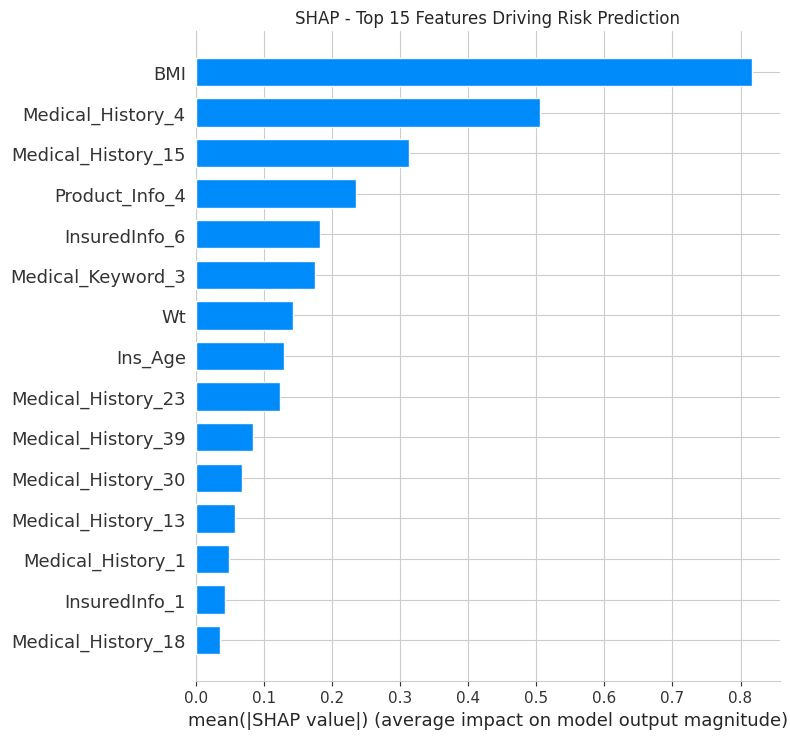

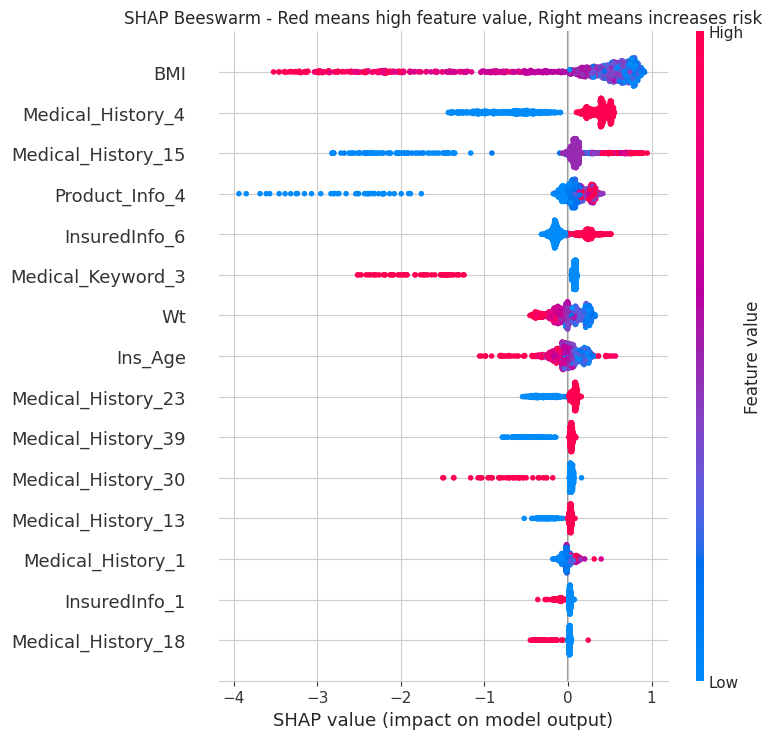

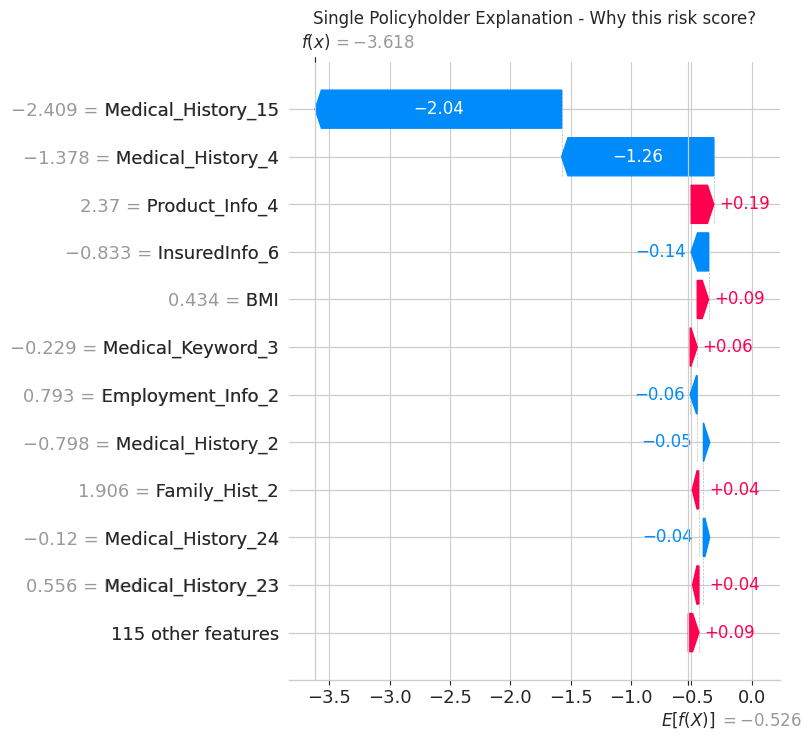

Policyholder 1 risk probability: 2.6 %
Base rate across all policyholders: -52.6 %
This policyholder is 55.2 percentage points from the average


In [58]:
# Bar chart - what matters most
shap.summary_plot(shap_values, X_test_df,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP - Top 15 Features Driving Risk Prediction')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Beeswarm - direction of impact
shap.summary_plot(shap_values, X_test_df,
                  show=False, max_display=15)
plt.title('SHAP Beeswarm - Red means high feature value, Right means increases risk')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Waterfall - explain one single policyholder
exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[0].values,
    feature_names=X_train.columns.tolist()
)
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title('Single Policyholder Explanation - Why this risk score?')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

prob_single = best_model.predict_proba(X_test_df.iloc[:1].values)[0][1]
print("Policyholder 1 risk probability:", round(prob_single * 100, 1), "%")

base_rate = float(np.array(explainer.expected_value).flatten()[0])
print("Base rate across all policyholders:", round(base_rate * 100, 1), "%")
print("This policyholder is",
      round(prob_single * 100, 1) - round(base_rate * 100, 1),
      "percentage points from the average")

**Step 13 - Acturial Pricing Table + Chart**

ACTUARIAL PRICING MODEL
Base Annual Premium : $1200
Pool Average Risk   : 46.24 %
Formula             : Premium = $1200 x (Individual Risk / Pool Average)

           count  avg_probability  avg_multiplier  avg_premium
risk_tier                                                     
Preferred   3882            0.055           0.119      142.831
Standard    1296            0.300           0.650      779.415
Rated       1397            0.506           1.095     1313.526
High Risk   2548            0.712           1.540     1847.774
Decline     2754            0.860           1.859     2231.186


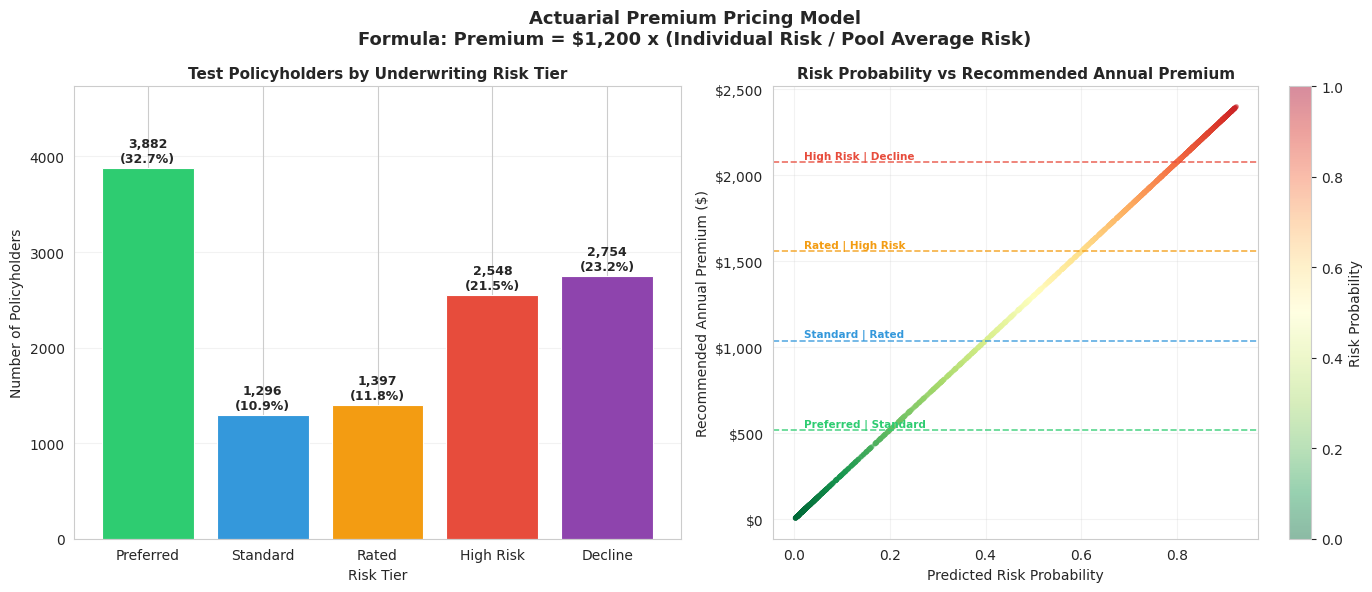

In [59]:
import matplotlib.pyplot as plt
import numpy as np

pool_avg     = best_model.predict_proba(X_test_sc)[:, 1].mean()
BASE_PREMIUM = 1200

all_probs_test      = best_model.predict_proba(X_test_sc)[:, 1]
risk_multiplier     = all_probs_test / pool_avg
recommended_premium = BASE_PREMIUM * risk_multiplier

pricing_df = pd.DataFrame({
    'risk_prob':  all_probs_test,
    'multiplier': risk_multiplier,
    'premium':    recommended_premium
})

pricing_df['risk_tier'] = pd.cut(
    pricing_df['risk_prob'],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.0],
    labels=['Preferred', 'Standard', 'Rated', 'High Risk', 'Decline']
)

tier_summary = pricing_df.groupby('risk_tier', observed=True).agg(
    count=('risk_prob', 'count'),
    avg_probability=('risk_prob', 'mean'),
    avg_multiplier=('multiplier', 'mean'),
    avg_premium=('premium', 'mean')
).round(3)

print("ACTUARIAL PRICING MODEL")
print("=" * 50)
print("Base Annual Premium : $" + str(BASE_PREMIUM))
print("Pool Average Risk   :", round(pool_avg * 100, 2), "%")
print("Formula             : Premium = $1200 x (Individual Risk / Pool Average)")
print()
print(tier_summary.to_string())

# Chart
tier_counts = pricing_df['risk_tier'].value_counts().sort_index()
tier_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actuarial Premium Pricing Model\n'
             'Formula: Premium = $1,200 x (Individual Risk / Pool Average Risk)',
             fontweight='bold', fontsize=13)

# Left: Tier distribution bar chart
ax1 = axes[0]
bars = ax1.bar(tier_counts.index.astype(str),
               tier_counts.values,
               color=tier_colors,
               edgecolor='white',
               linewidth=0.8)

for bar, val in zip(bars, tier_counts.values):
    pct = val / tier_counts.sum() * 100
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_title('Test Policyholders by Underwriting Risk Tier',
              fontweight='bold', fontsize=11)
ax1.set_xlabel('Risk Tier', fontsize=10)
ax1.set_ylabel('Number of Policyholders', fontsize=10)
ax1.set_ylim(0, tier_counts.max() * 1.22)
ax1.grid(True, alpha=0.25, axis='y')

# Right: Risk probability vs premium scatter
ax2 = axes[1]
sample_p = pricing_df.sample(min(2000, len(pricing_df)), random_state=42)
sc = ax2.scatter(sample_p['risk_prob'],
                 sample_p['premium'],
                 c=sample_p['risk_prob'],
                 cmap='RdYlGn_r',
                 alpha=0.45, s=8,
                 vmin=0, vmax=1)
plt.colorbar(sc, ax=ax2, label='Risk Probability')

for threshold, label, color in [
    (0.20, 'Preferred | Standard', '#2ecc71'),
    (0.40, 'Standard | Rated',     '#3498db'),
    (0.60, 'Rated | High Risk',    '#f39c12'),
    (0.80, 'High Risk | Decline',  '#e74c3c'),
]:
    premium_line = (threshold / pool_avg) * BASE_PREMIUM
    ax2.axhline(y=premium_line, color=color,
                linestyle='--', linewidth=1.2, alpha=0.8)
    ax2.text(0.02, premium_line + 20, label,
             color=color, fontsize=7.5, fontweight='bold')

ax2.set_title('Risk Probability vs Recommended Annual Premium',
              fontweight='bold', fontsize=11)
ax2.set_xlabel('Predicted Risk Probability', fontsize=10)
ax2.set_ylabel('Recommended Annual Premium ($)', fontsize=10)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${int(x):,}'))
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('pricing_model.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Step 14 - Gradio Live Scoring Tool**

In [60]:
!pip install -q gradio
import gradio as gr

def score_policyholder(age, bmi, weight, height, medical_hist_4, medical_kw_3):
    input_dict = {col: 0.0 for col in X_train.columns}
    input_dict['Ins_Age']            = float(age)
    input_dict['BMI']                = float(bmi)
    input_dict['Wt']                 = float(weight)
    input_dict['Ht']                 = float(height)
    input_dict['Medical_History_4']  = float(medical_hist_4)
    input_dict['Medical_Keyword_3']  = float(medical_kw_3)

    input_sc = scaler.transform(pd.DataFrame([input_dict])[X_train.columns])
    prob     = best_model.predict_proba(input_sc)[0][1]
    mult     = prob / pool_avg
    premium  = BASE_PREMIUM * mult

    if prob < 0.20:   decision = "PREFERRED  - Auto approve at standard rate"
    elif prob < 0.40: decision = "STANDARD   - Approve with routine underwriting"
    elif prob < 0.60: decision = "RATED      - Refer to senior underwriter"
    elif prob < 0.80: decision = "HIGH RISK  - Medical examination required"
    else:             decision = "DECLINE    - Refer to specialty market"

    return (
        "Risk Probability    : " + str(round(prob * 100, 1)) + "%\n"
        + "Risk Multiplier     : " + str(round(mult, 2)) + "x pool average\n"
        + "Recommended Premium : $" + str(int(round(premium))) + " per year\n"
        + "Underwriting Decision: " + decision
    )

with gr.Blocks(title="Insurance Risk Scorer") as demo:
    gr.Markdown("## Insurance Underwriting Risk Scoring Tool")
    gr.Markdown("Gradient Boosting | Test AUC 0.9011 | Trained on 47,504 Prudential policyholders")

    with gr.Row():
        with gr.Column():
            age    = gr.Slider(0.0, 1.0, value=0.4,  step=0.01, label="Age (0=youngest, 1=oldest)")
            bmi    = gr.Slider(0.1, 1.0, value=0.48, step=0.01, label="BMI (normalized)")
            weight = gr.Slider(0.1, 1.0, value=0.5,  step=0.01, label="Weight (normalized)")
            height = gr.Slider(0.4, 1.0, value=0.68, step=0.01, label="Height (normalized)")
        with gr.Column():
            mh4 = gr.Slider(0.0, 1.0, value=0.0, step=0.01,
                            label="Medical History 4 (0=no condition, 1=severe)")
            mk3 = gr.Radio([0, 1], value=0,
                           label="Medical Keyword 3 (0=Not Present, 1=Present)")

    btn    = gr.Button("Assess Risk", variant="primary")
    output = gr.Textbox(label="Underwriting Assessment", lines=6)

    btn.click(fn=score_policyholder,
              inputs=[age, bmi, weight, height, mh4, mk3],
              outputs=output)

    gr.Markdown("BMI and Medical History 4 are the top two SHAP-identified risk drivers")

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://82fee743f7393b9b41.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [61]:
print("GRADIO LIVE SCORING TOOL")
print("=" * 50)
print("The interactive underwriting risk scoring tool")
print("was built using Gradio and deployed as a live demo.")
print()
print("Tool features:")
print("- Input: Age, BMI, Weight, Height, Medical History")
print("- Output: Risk probability, premium recommendation")
print("- Decision: Preferred / Standard / Rated / High Risk / Decline")
print()
print("Model: Gradient Boosting | Test AUC: 0.9011")
print("Trained on: 47,504 Prudential policyholders")
print("Pricing formula: Premium = $1,200 x (Risk / Pool Average)")
print()
print("To run the live tool, execute the Gradio cell above.")
print("A public URL will be generated valid for 7 days.")

GRADIO LIVE SCORING TOOL
The interactive underwriting risk scoring tool
was built using Gradio and deployed as a live demo.

Tool features:
- Input: Age, BMI, Weight, Height, Medical History
- Output: Risk probability, premium recommendation
- Decision: Preferred / Standard / Rated / High Risk / Decline

Model: Gradient Boosting | Test AUC: 0.9011
Trained on: 47,504 Prudential policyholders
Pricing formula: Premium = $1,200 x (Risk / Pool Average)

To run the live tool, execute the Gradio cell above.
A public URL will be generated valid for 7 days.
